
| Parameter |Description| Content type |
|---|----|---|
|age| Age in years| integer |
|gender| Male or Female|integer (1 or 2)|
| bmi | Body mass index | float |
|no_of_children| Number of children | integer|
|smoker| Whether smoker or not | integer (0 or 1)|
|region| Which US region - NW, NE, SW, SE | integer (1,2,3 or 4 respectively)| 
|charges| Annual Insurance charges in USD | float|

## Objectives 
In this project, you will:
 - Load the data as a `pandas` dataframe
 - Clean the data, taking care of the blank entries
 - Run exploratory data analysis (EDA) and identify the attributes that most affect the `charges`
 - Develop single variable and multi variable Linear Regression models for predicting the `charges`
 - Use Ridge regression to refine the performance of Linear regression models. 

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [2]:
def download (url, fileName):
    response = requests.get(url)
    if(response.status_code == 200):
        with open(fileName, "wb") as f:
            f.write(response.content)

In [3]:
filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'
file_name = 'medical_data.csv'

In [4]:
download (filepath, file_name)

In [5]:
df = pd.read_csv(file_name)
df.head()

,19,1,27.9,0,1.1,3,16884.924
0,18,2,33.770,1,0,4,1725.55230
1,28,2,33.000,3,0,4,4449.46200
2,33,2,22.705,0,0,1,21984.47061
3,32,2,28.880,0,0,1,3866.85520
4,31,1,25.740,0,?,4,3756.62160


In [6]:
headers = ["age", "gender", "bmi", "no_of_children", "smoker", "region", "charges"]
df.columns = headers

In [7]:
df.head()

,age,gender,bmi,no_of_children,smoker,region,charges
0,18,2,33.770,1,0,4,1725.55230
1,28,2,33.000,3,0,4,4449.46200
2,33,2,22.705,0,0,1,21984.47061
3,32,2,28.880,0,0,1,3866.85520
4,31,1,25.740,0,?,4,3756.62160


# Task 2 : Data Wrangling


In [8]:
# Use `dataframe.info()` to identify the columns that have some 'Null' (or NaN) information.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2771 entries, 0 to 2770
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2771 non-null   str    
 1   gender          2771 non-null   int64  
 2   bmi             2771 non-null   float64
 3   no_of_children  2771 non-null   int64  
 4   smoker          2771 non-null   str    
 5   region          2771 non-null   int64  
 6   charges         2771 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 151.7 KB


In [14]:
df = df.replace('?', np.nan)
df.isnull().sum()

age               4
gender            0
bmi               0
no_of_children    0
smoker            7
region            0
charges           0
dtype: int64

In [22]:
# update the NaN value of age and smoker by their mean value and most frequency value with respectively.

#Calculate mean of the age
age_mean = df["age"].astype("float").mean(axis= 0)

#replace NaN values with age_mean
df['age'] = df['age'].fillna(age_mean)
print(df['age'].isnull().sum())

0


In [26]:
# Calculate most frequency value of smoker 
df["smoker"].value_counts()
smoker_freq = df["smoker"].value_counts().idxmax()

In [27]:
# Replace it with NaN values
df["smoker"] = df["smoker"].fillna(smoker_freq)
df["smoker"].isnull().sum()

np.int64(0)

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2771 entries, 0 to 2770
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2771 non-null   object 
 1   gender          2771 non-null   int64  
 2   bmi             2771 non-null   float64
 3   no_of_children  2771 non-null   int64  
 4   smoker          2771 non-null   str    
 5   region          2771 non-null   int64  
 6   charges         2771 non-null   float64
dtypes: float64(2), int64(3), object(1), str(1)
memory usage: 151.7+ KB


In [29]:
# change the data types of age and smoker to int and int respecticvely
df[["age", "smoker"]] = df[["age", "smoker"]].astype("int")

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2771 entries, 0 to 2770
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2771 non-null   int64  
 1   gender          2771 non-null   int64  
 2   bmi             2771 non-null   float64
 3   no_of_children  2771 non-null   int64  
 4   smoker          2771 non-null   int64  
 5   region          2771 non-null   int64  
 6   charges         2771 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 151.7 KB


# Task 3 : Exploratory Data Analysis (EDA)

Implement the regression plot for `charges` with respect to `bmi`. 


(0.0, 66902.8557155)

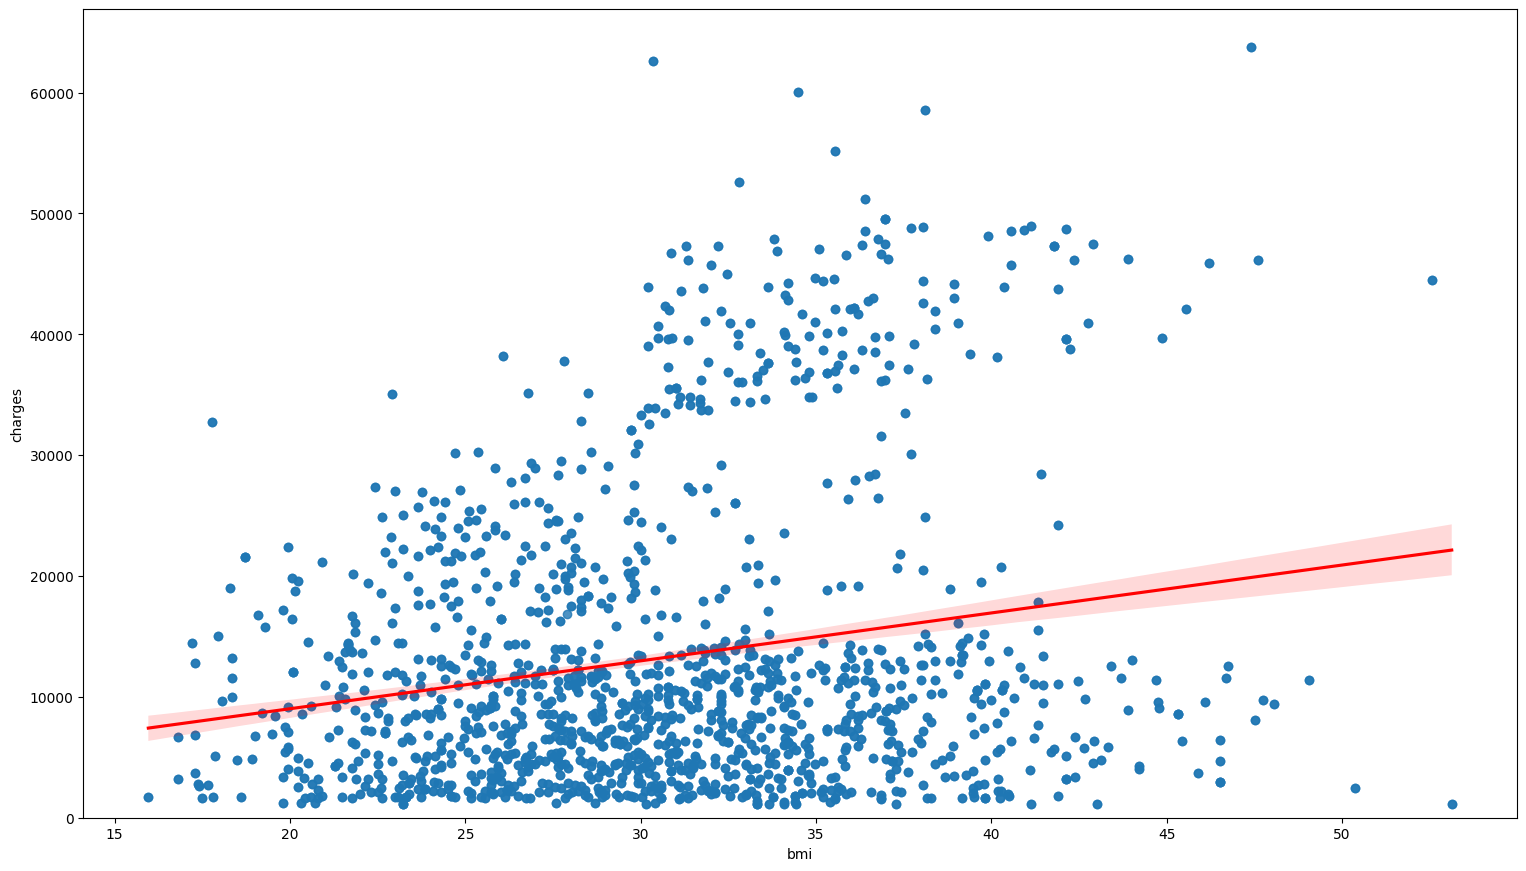

In [38]:
fig, ax = plt.subplots()
fig.set_size_inches(18.5, 10.5)
sns.regplot(data = df, x = "bmi", y = "charges", ax=ax, line_kws={"color": "red"})
plt.ylim(0,)


Implement the box plot for `charges` with respect to `smoker`.


<Axes: xlabel='smoker', ylabel='charges'>

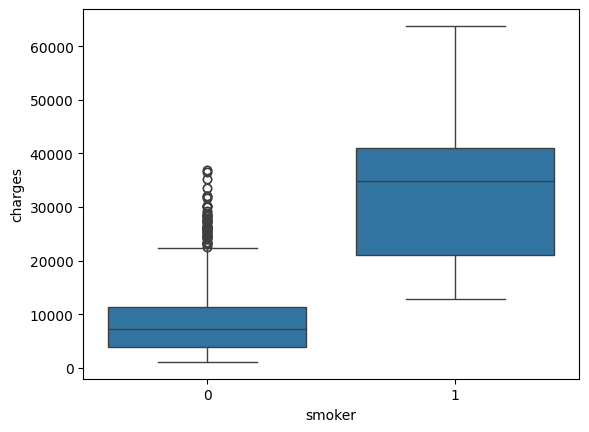

In [43]:
sns.boxplot(data = df ,  x = 'smoker', y = 'charges')

Print the correlation matrix for the dataset.


In [44]:
print(df.corr())

                     age    gender       bmi  no_of_children    smoker  \
age             1.000000 -0.026584  0.112859        0.037126 -0.022290   
gender         -0.026584  1.000000  0.042766        0.015693  0.083125   
bmi             0.112859  0.042766  1.000000       -0.001642  0.011824   
no_of_children  0.037126  0.015693 -0.001642        1.000000  0.007016   
smoker         -0.022290  0.083125  0.011824        0.007016  1.000000   
region         -0.006969  0.022360  0.271200       -0.025594  0.053839   
charges         0.298892  0.062959  0.199906        0.066551  0.789141   

                  region   charges  
age            -0.006969  0.298892  
gender          0.022360  0.062959  
bmi             0.271200  0.199906  
no_of_children -0.025594  0.066551  
smoker          0.053839  0.789141  
region          1.000000  0.054018  
charges         0.054018  1.000000  


# Task 4 : Model Development

Fit a linear regression model that may be used to predict the `charges` value, just by using the `smoker` attribute of the dataset. Print the $ R^2 $ score of this model.


In [47]:
from sklearn.linear_model import LinearRegression

x = df[['smoker']]
y = df['charges']

lm = LinearRegression()

lm.fit(x,y)

#print the score of the  model
print(lm.score(x , y))


0.6227430384081843


Fit a linear regression model that may be used to predict the `charges` value, just by using all other attributes of the dataset. Print the $ R^2 $ score of this model. You should see an improvement in the performance.


In [55]:
df_new = df.drop(['charges'],axis=1)
df_new.head()

,age,gender,bmi,no_of_children,smoker,region
0,18,2,33.770,1,0,4
1,28,2,33.000,3,0,4
2,33,2,22.705,0,0,1
3,32,2,28.880,0,0,1
4,31,1,25.740,0,0,4


In [56]:
lm_new = LinearRegression()

lm_new.fit(df_new, y)
print(lm_new.score(df_new, y))

0.7505888658724134


Create a training pipeline that uses `StandardScaler()`, `PolynomialFeatures()` and `LinearRegression()` to create a model that can predict the `charges` value using all the other attributes of the dataset. There should be even further improvement in the performance.


In [58]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score 

input = [("polynomial", PolynomialFeatures(degree=3, include_bias=False)), ("scaler",StandardScaler()),
         ("model", LinearRegression())]

pipe = Pipeline(input)
pipe.fit(df_new, y)

yhat = pipe.predict(df_new)
print("Score: ", r2_score(y,yhat))



Score:  0.8546560418650284
